In [73]:
#bibliotecas e arquivos

import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [74]:
#carregar as bases:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
gender_submission = pd.read_csv('/kaggle/input/competitions/titanic/gender_submission.csv')

In [75]:
#visualizar train:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [76]:
#tamanho de train:
train.shape

(891, 12)

In [77]:
#visualizar test:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [78]:
#tamanho do test:
test.shape

(418, 11)

In [79]:
#visualizar exemplo de submissão:
gender_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


# 1. Análise Exploratória dos Dados

Nesta etapa, será realizada uma análise inicial do conjunto de treinamento para compreender sua estrutura, identificar valores ausentes e analisar a distribuição da variável-alvo `Survived`.

In [80]:
#estrutura da base:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [81]:
#valores ausentes:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [82]:
#percentual de ausentes:
(train.isnull().sum() / len(train) * 100).round(2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [83]:
#estatísticas numéricas:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [84]:
#quantidade de sobreviventes:
train['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [85]:
#Relação entre sexo e sobrevivência:
# Qual foi a taxa média de sobrevivência de homens e mulheres?

train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [86]:
#tabela sexo × sobrevivência:
pd.crosstab(train['Sex'], train['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [87]:
# Classe do bilhete e taxa de sobrevivência

train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [88]:
#tabela classe × sobrevivência:
pd.crosstab(train['Pclass'], train['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [89]:
# Cruzando sexo e classe do bilhete

train.groupby(['Sex', 'Pclass'])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

### Sexo e classe do bilhete

A análise exploratória revelou diferenças relevantes nas taxas de sobrevivência de acordo com o sexo e a classe do bilhete. Mulheres apresentaram taxa de sobrevivência de aproximadamente 74,2%, enquanto entre os homens essa taxa foi de apenas 18,9%.

A classe do bilhete também apresentou associação com a sobrevivência: passageiros da primeira classe tiveram taxa de aproximadamente 63,0%, enquanto na terceira classe a taxa foi de apenas 24,2%.

Ao combinar sexo e classe, a diferença se torna ainda mais evidente. Mulheres da primeira e segunda classes apresentaram taxas superiores a 90%, enquanto mulheres da terceira classe tiveram taxa de 50%. Entre os homens, a sobrevivência foi inferior a 37% em todas as classes.

Esses resultados indicam que `Sex` e `Pclass` são características potencialmente relevantes para a construção do modelo de classificação.

In [90]:
# Próxima pergunta: e a idade?

train.groupby('Survived')['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [91]:
#mediana da idade:
train.groupby('Survived')['Age'].median()

Survived
0    28.0
1    28.0
Name: Age, dtype: float64

In [92]:
#criar faixas etárias:
train['AgeGroup'] = pd.cut(
    train['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[
        'Criança',
        'Adolescente',
        'Adulto jovem',
        'Adulto',
        'Idoso'
    ]
)

train.groupby(
    'AgeGroup',
    observed=False
)['Survived'].agg(['count', 'mean'])

,count,mean
AgeGroup,,
Criança,69,0.579710
Adolescente,70,0.428571
Adulto jovem,358,0.382682
Adulto,195,0.400000
Idoso,22,0.227273


### Idade e sobrevivência

A idade média dos passageiros que sobreviveram foi ligeiramente inferior à dos que não sobreviveram. Entretanto, ambos os grupos apresentaram mediana de 28 anos, indicando que a diferença geral entre as idades não é muito acentuada.

A análise por faixas etárias revelou um padrão mais relevante: crianças apresentaram taxa de sobrevivência de aproximadamente 58%, enquanto passageiros idosos apresentaram taxa de aproximadamente 23%.

Portanto, a idade parece conter informação útil para o modelo, embora sua relação com a sobrevivência seja menos evidente que as observadas para sexo e classe do bilhete.

In [93]:
# Verificando o ponto de embarque

train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [94]:
train.groupby('Embarked')['Survived'].agg(['count', 'mean'])

,count,mean
Embarked,,
C,168,0.553571
Q,77,0.389610
S,644,0.336957


### Porto de embarque

A maioria dos passageiros embarcou em Southampton, com 644 registros. Entretanto, Cherbourg apresentou a maior taxa de sobrevivência, aproximadamente 55,4%, enquanto Queenstown apresentou 39,0% e Southampton 33,7%.

Esse resultado sugere que `Embarked` pode contribuir para o modelo, embora a associação possa estar relacionada também a outras características dos passageiros, como sexo e classe do bilhete.

In [ ]:
# Agora, vamos analisar Fare

train.groupby('Survived')['Fare'].agg(['count', 'mean', 'median'])

In [95]:
#quartis da tarifa:
train['FareGroup'] = pd.qcut(
    train['Fare'],
    q=4,
    labels=[
        'Baixa',
        'Média-baixa',
        'Média-alta',
        'Alta'
    ]
)

train.groupby(
    'FareGroup',
    observed=False
)['Survived'].agg(['count', 'mean'])

,count,mean
FareGroup,,
Baixa,223,0.197309
Média-baixa,224,0.303571
Média-alta,222,0.454955
Alta,222,0.581081


### Tarifa e sobrevivência

A tarifa apresentou associação relevante com a sobrevivência. Passageiros que sobreviveram pagaram, em média, tarifas mais elevadas que aqueles que não sobreviveram.

A análise por quartis também mostrou aumento progressivo da taxa de sobrevivência conforme a faixa de tarifa, variando de aproximadamente 19,7% no grupo de menor tarifa para 58,1% no grupo de maior tarifa.

Entretanto, essa associação deve ser interpretada com cautela, pois a tarifa também pode estar relacionada a outras características, especialmente à classe do bilhete.

In [96]:
#ausentes no teste:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

# 2. Preparação dos Dados para Machine Learning

Nesta etapa, serão selecionadas as características utilizadas pelo modelo, realizado o tratamento de valores ausentes e a transformação das variáveis categóricas.

In [97]:
#definir features e target:

features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

X = train[features]
y = train['Survived']

In [98]:
#conferir X:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [99]:
#conferir y:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [100]:
#separar treino e validação:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_valid.shape

((712, 7), (179, 7))

In [103]:
#separar tipos de variáveis:
numeric_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]

categorical_features = [
    'Sex',
    'Embarked'
]

print(numeric_features)
print(categorical_features)

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
['Sex', 'Embarked']


In [104]:
#pipeline numérico:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [105]:
#pipeline categórico:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [106]:
#juntar transformações:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [107]:
#Regressão Logística:
#criar modelo:
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

In [108]:
#treinar:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [110]:
#fazer previsões:
y_pred = model.predict(X_valid)

In [111]:
#acurácia:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, y_pred)

print(f'Acurácia: {accuracy:.4f}')
print(f'Acurácia: {accuracy * 100:.2f}%')

Acurácia: 0.8045
Acurácia: 80.45%


In [112]:
#matriz de confusão:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, y_pred)

cm

array([[98, 12],
       [23, 46]])

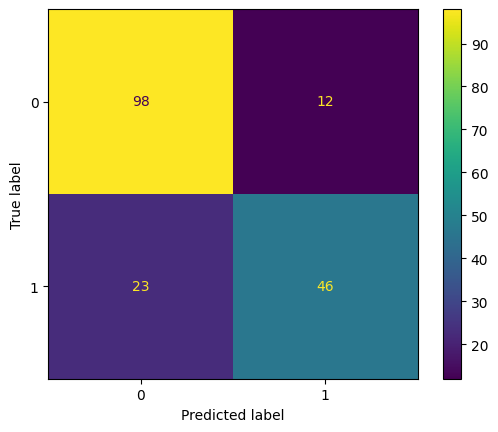

In [113]:
#visualizar matriz:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred
)

In [114]:
#relatório de classificação:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_valid,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [115]:
#validação cruzada:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print('Acurácias:', scores)
print(f'Média: {scores.mean():.4f}')
print(f'Desvio padrão: {scores.std():.4f}')

Acurácias: [0.77653631 0.78651685 0.78089888 0.76966292 0.8258427 ]
Média: 0.7879
Desvio padrão: 0.0198


### Regressão Logística

O modelo de Regressão Logística alcançou acurácia de aproximadamente 80,45% no conjunto de validação.

A matriz de confusão mostrou melhor desempenho na identificação dos passageiros que não sobreviveram. O recall para a classe dos sobreviventes foi inferior, indicando maior dificuldade do modelo em identificar todos os passageiros que efetivamente sobreviveram.

Na validação cruzada com cinco divisões, o modelo apresentou acurácia média de aproximadamente 78,79%, indicando desempenho relativamente consistente entre diferentes subconjuntos dos dados.

In [116]:
#Random Forest:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [117]:
#validação cruzada Random Forest:
rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print('Acurácias:', rf_scores)
print(f'Média: {rf_scores.mean():.4f}')
print(f'Desvio padrão: {rf_scores.std():.4f}')

Acurácias: [0.77094972 0.81460674 0.83707865 0.76966292 0.83146067]
Média: 0.8048
Desvio padrão: 0.0291


In [118]:
#comparar os modelos:
print(
    f'Regressão Logística: {scores.mean() * 100:.2f}%'
)

print(
    f'Random Forest: {rf_scores.mean() * 100:.2f}%'
)

Regressão Logística: 78.79%
Random Forest: 80.48%


In [119]:
#treinar Random Forest:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [120]:
#prever validação:
rf_pred = rf_model.predict(X_valid)

In [121]:
#acurácia:
rf_accuracy = accuracy_score(
    y_valid,
    rf_pred
)

print(
    f'Acurácia Random Forest: {rf_accuracy * 100:.2f}%'
)

Acurácia Random Forest: 81.56%


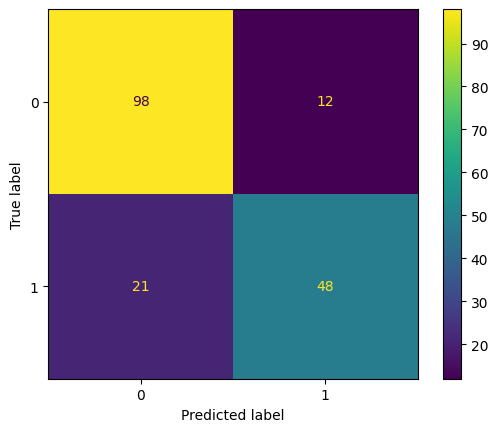

In [122]:
#matriz de confusão:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    rf_pred
)

In [123]:
#relatório Random Forest:
print(
    classification_report(
        y_valid,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



### Comparação dos modelos

O Random Forest apresentou desempenho superior à Regressão Logística.

Na validação, alcançou acurácia de aproximadamente 81,56%, além de apresentar melhor recall e F1-score para a classe dos sobreviventes.

Na validação cruzada, também obteve maior acurácia média, com aproximadamente 80,48%, contra 78,79% da Regressão Logística.

Com base nesses resultados, o Random Forest foi selecionado para gerar a primeira submissão.

# 3. Modelo Final e Submissão

Após a comparação entre Regressão Logística e Random Forest, o Random Forest foi selecionado por apresentar melhor desempenho médio na validação cruzada e melhores resultados na identificação dos sobreviventes.

O modelo final será treinado utilizando todos os 891 registros disponíveis no conjunto de treinamento e utilizado para prever a variável `Survived` dos 418 passageiros do conjunto de teste.

In [125]:
#preparar test:
X_test = test[features]

In [126]:
#treinar com todos os dados:
rf_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [127]:
#prever os 418 passageiros:
test_predictions = rf_model.predict(X_test)

test_predictions[:20]

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1])

In [128]:
#criar submissão:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


In [129]:
#verificar:
submission.shape

(418, 2)

In [130]:
#verificar previsões:
submission['Survived'].value_counts()

Survived
0    266
1    152
Name: count, dtype: int64

In [131]:
#verificar nulos:
submission.isnull().sum()

PassengerId    0
Survived       0
dtype: int64

In [132]:
#gerar arquivo final:
submission.to_csv(
    '/kaggle/working/submission.csv',
    index=False
)

print('submission.csv criado com sucesso!')

submission.csv criado com sucesso!


In [133]:
submission_check = pd.read_csv(
    '/kaggle/working/submission.csv'
)

display(submission_check.head())

print(submission_check.shape)

print(submission_check.isnull().sum())

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


(418, 2)
PassengerId    0
Survived       0
dtype: int64


### Submissão

O modelo final de Random Forest foi treinado utilizando todos os 891 registros do conjunto de treinamento.

Em seguida, foram realizadas previsões para os 418 passageiros do conjunto de teste.

As previsões foram exportadas para o arquivo `submission.csv`, contendo as colunas `PassengerId` e `Survived`, no formato exigido pela competição Titanic do Kaggle.